### 1. Dataset

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
main_folder = 'raw_dataset/dataset'

banana1_folder = os.path.join(main_folder, '1st_class_banana')
apple1_folder = os.path.join(main_folder, '1st_class_apple')
orange1_folder = os.path.join(main_folder, '1st_class_oranges')

banana2_folder = os.path.join(main_folder, '2nd_class_banana')
apple2_folder = os.path.join(main_folder, '2nd_class_apple')
orange2_folder = os.path.join(main_folder, '2nd_class_orange')

banana3_folder = os.path.join(main_folder, 'rotten_banana')
apple3_folder = os.path.join(main_folder, 'rotten_apple')
orange3_folder = os.path.join(main_folder, 'rotten_orange')

# Check the number of images
print(f'1st class banana images: {len(os.listdir(banana1_folder))}')
print(f'1st class apple images: {len(os.listdir(apple1_folder))}')
print(f'1st class orange images: {len(os.listdir(orange1_folder))}')

print(f'2nd class banana images: {len(os.listdir(banana2_folder))}')
print(f'2nd class apple images: {len(os.listdir(apple2_folder))}')
print(f'2nd class orange images: {len(os.listdir(orange2_folder))}')

print(f'rotten banana images: {len(os.listdir(banana3_folder))}')
print(f'rotten apple images: {len(os.listdir(apple3_folder))}')
print(f'rotten orange images: {len(os.listdir(orange3_folder))}')

1st class banana images: 1962
1st class apple images: 2088
1st class orange images: 1853
2nd class banana images: 450
2nd class apple images: 441
2nd class orange images: 467
rotten banana images: 2748
rotten apple images: 2942
rotten orange images: 1998


In [ ]:
# Folder paths where the images of each class are stored
folder_paths = [
    apple1_folder,
    banana1_folder,
    orange1_folder,
    apple2_folder,
    banana2_folder,
    orange2_folder,
    apple3_folder,
    banana3_folder,
    orange3_folder
]

# Class labels for the images (same order as folder_paths)
class_names = [
    '1st_class_apple',
    '1st_class_banana',
    '1st_class_orange',
    '2nd_class_apple',
    '2nd_class_banana',
    '2nd_class_orange',
    'rotten_apple',
    'rotten_banana',
    'rotten_orange'
]

# Target size to resize the images
target_size = (32,32)

# Maximum number of images to load per class
# Since I have only ~450 AI-generated images for each "second class" class, and the rest is over ~2000 for each other class, I will only use max of 440 images per class 
max_images_per_class = 440

# Arrays to store the images (X) and class labels (y)
X = []
y = []

for i in range(len(folder_paths)):
    count = 0
    if len(X) == 9 * max_images_per_class: break
    for filename in os.listdir(folder_paths[i]):
        if count >= max_images_per_class:
            break
        file_extension = os.path.splitext(filename)[1].lower()
        if file_extension in (".jpg", ".jpeg", ".png"):
            image_filename = os.path.join(folder_paths[i], filename)
            try:
                # Read the image file using scikit-image
                image = ski.io.imread(image_filename)
                # Resize the image to the target_size
                image_resized = ski.transform.resize(image, target_size)
                # Insert the image into array X
                X.append(image_resized)
                # Insert the class label into array y
                y.append(class_names[i])
                count += 1
            except Exception as e:
                print(f"Error loading image {image_filename}: {e}")

# Convert arrays into numpy arrays
X = np.array(X)
y = np.array(y)

print(f'Total images loaded: {len(X)}')
print(f'Image shape: {X[0].shape}')
print(f'Labels shape: {y.shape}')
print(f'\nImages per class:')
for name in class_names:
    print(f'  {name}: {np.sum(y == name)}')


Total images loaded: 3960
Image shape: (32, 32, 3)
Labels shape: (3960,)

Images per class:
  1st_class_apple: 440
  1st_class_banana: 440
  1st_class_orange: 440
  2nd_class_apple: 440
  2nd_class_banana: 440
  2nd_class_orange: 440
  rotten_apple: 440
  rotten_banana: 440
  rotten_orange: 440


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 1/10,
                                                    random_state = 0)
                                                    
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 0)
                                                  

print(f'Training set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')
print(f'Test set size: {len(X_test)}')

Training set size: 3168
Validation set size: 396
Test set size: 396


### 2. Preprocessing

In [5]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
label_encoder = LabelEncoder()

label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f'Unique labels in y_train: {np.unique(y_train)}')

y_train_encoded = to_categorical(label_encoder.transform(y_train), num_classes=9)
y_val_encoded = to_categorical(label_encoder.transform(y_val), num_classes=9)
y_test_encoded = to_categorical(label_encoder.transform(y_test), num_classes=9)

print(f'Encoded y_train sample: {y_train_encoded[:10]}')
print(f'Encoded y_train sample: {y_val_encoded[:10]}')
print(f'Encoded y_train sample: {y_test_encoded[:10]}')


Unique labels in y_train: ['1st_class_apple' '1st_class_banana' '1st_class_orange' '2nd_class_apple'
 '2nd_class_banana' '2nd_class_orange' 'rotten_apple' 'rotten_banana'
 'rotten_orange']
Encoded y_train sample: [[0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 

### 3. MLP Architecture

In [18]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

def build_cnn_model(print_summary=False):
    model = Sequential()

    model.add(Input(shape=(32, 32, 3)))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256, activation='relu'))
    
    model.add(Dense(9, activation='softmax'))

    
    if print_summary:
        model.summary()
    
    return model

# Build and display the model
model = build_cnn_model(print_summary=True)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,017 (6.51 MB)

 Trainable params: 1,707,017 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### 4. MLP Training

In [19]:
def compile_cnn_model(model):
    
    # Compile the model with binary_crossentropy loss, adam optimizer, and accuracy metric
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

model = compile_cnn_model(model)

In [20]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(patience=2)
H = model.fit(X_train, y_train_encoded, validation_data=(X_val, y_val_encoded), batch_size=16, validation_batch_size=16, epochs=10, callbacks=[early_stopping])

Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5211 - loss: 1.3278 - val_accuracy: 0.5328 - val_loss: 1.0917
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7203 - loss: 0.7654 - val_accuracy: 0.7980 - val_loss: 0.6122
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7721 - loss: 0.6151 - val_accuracy: 0.7197 - val_loss: 0.7037
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7951 - loss: 0.5449 - val_accuracy: 0.8207 - val_loss: 0.4984
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8226 - loss: 0.4900 - val_accuracy: 0.6465 - val_loss: 0.8953
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8264 - loss: 0.4739 - val_accuracy: 0.8409 - val_loss: 0.4198
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8412 - loss: 0.4279 - val_accuracy: 0.8460 - val_loss: 0.4502
Epoch 8/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8453 - loss: 0.4062 - val_accur

### 5. MLP Evaluation

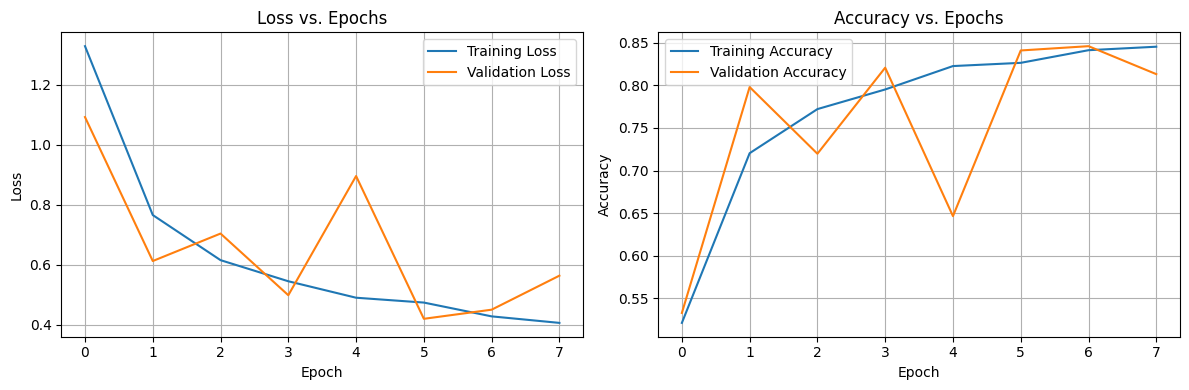

In [21]:
def plot_training_history(H):
    # Plot loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(H.history['loss'], label='Training Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epochs')
    plt.grid(True)
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(H.history['accuracy'], label='Training Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epochs')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(H)

In [22]:
test_loss, test_acc = model.evaluate(
    X_test, y_test_encoded
)

print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7980 - loss: 0.5837 
Test accuracy: 0.7980
Test loss: 0.5837


### 6. Baseline Accuracy

Final Baseline Accuracy: 79%